**Reading Images & Histograms**

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os as os
from skimage.metrics import peak_signal_noise_ratio, structural_similarity


**Population Generation**

In [17]:
def initialize_population(pop_size, K, L=256):
  population = []
  for _ in range(pop_size):
    candidate = np.sort(np.random.randint(1, L-1, size=K))
    population.append(candidate)
  return np.array(population)

#pop = initialize_population(10, 3)
#print(pop)

**Objective Functions**

Variance (Otsu): Measures how spread out class means are. High variance = classes are distinct.

Otsu’s Variance
Formula:

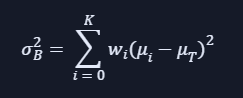

𝑤𝑖: probability (weight) of class 𝑖.
𝜇𝑖: mean intensity of class 𝑖.
𝜇𝑇: overall mean intensity.
Goal: maximize between-class variance → classes are well separated.

In [18]:
def otsu_objective(thresholds, hist):
  thresholds = np.sort(thresholds)
  thresholds = np.sort(thresholds.astype(int))
  bins = np.arange(len(hist))
  classes = np.split(hist, thresholds)
  means = [np.mean(c) for c in classes]
  weights = [c.sum() for c in classes]
  overall_mean = np.sum(bins * hist)
  variance = sum([w * (m - overall_mean)**2 for w, m in zip(weights, means)])
  return -variance


Entropy (Kapur): Measures uncertainty/information. High entropy = segmentation captures more detail.

Kapur’s Entropy
Formula:

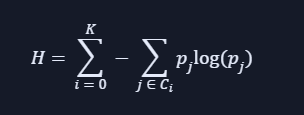

𝑝𝑗: probability of intensity 𝑗.
𝐶𝑖: pixels in class 𝑖.
Goal: maximize entropy → classes contain maximum information

In [19]:
def kapur_objective(thresholds, hist):
  thresholds = np.sort(thresholds)
  thresholds = np.sort(thresholds.astype(int))
  classes = np.split(hist, thresholds)
  entropy = sum([-np.sum(c * np.log(c + 1e-12)) for c in classes])
  return -entropy

Tsallis Entropy: Generalized entropy that handles non-linear, long-range correlations (useful in medical images)

Tsallis Entropy
Formula:

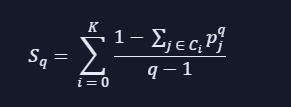

𝑞: entropic index (controls sensitivity).
Goal: maximize non-extensive entropy → captures complex distributions better than Shannon entropy.

In [20]:
def tsallis_objective(thresholds, hist, q=0.8):
  thresholds = np.sort(thresholds)
  thresholds = np.sort(thresholds.astype(int))
  classes = np.split(hist, thresholds)
  tsallis = sum([(1 - np.sum(c**q)) / (q-1) for c in classes])
  return -tsallis

In [21]:
objective_functions = {
    "Otsu": otsu_objective,
    "Kapur": kapur_objective,
    "Tsallis": tsallis_objective
}

**Mutation & Crossover (Standard DE)**

**Mutation**

In DE, mutation creates a mutant vector by combining existing candidates

Standard DE/rand/1:


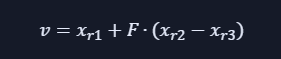


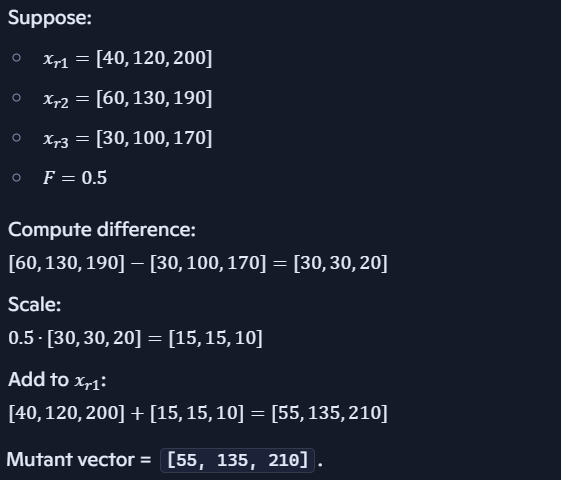

𝐹: scaling factor (0–1). Controls how far thresholds move.

Intuition: It shifts thresholds toward new regions in the search space.


**Crossover**

Combines the mutant vector with the target vector (parent).

Binomial crossover:
For each threshold position, with probability
𝐶𝑅, take from mutant; otherwise, take from parent.


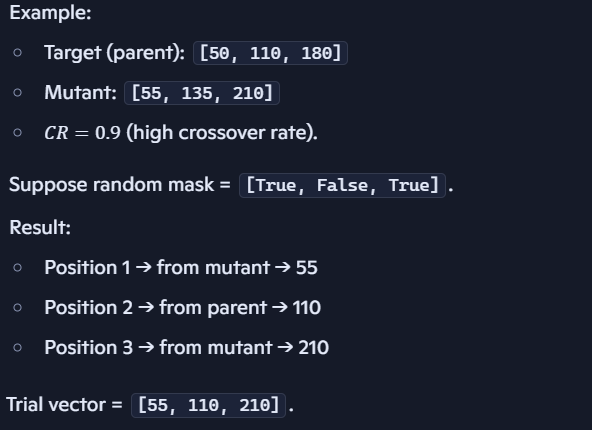


𝐶𝑅: crossover rate (0–1). Controls how much mixing happens.

Intuition: Ensures diversity by blending solutions.

**Parameters F and CR**

**F (Scaling Factor):**

Controls mutation step size.

Typical values: 0.4–0.9.

Larger F = more exploration, smaller F = fine-tuning.

**CR (Crossover Rate):**

Probability of taking mutant values during crossover.

Typical values: 0.7–0.9.

Higher CR = more diversity, lower CR = more stability.

In [22]:
def mutation(pop, F=0.5):
  idxs = np.random.choice(len(pop), 3, replace=False)
  r1, r2, r3 = pop[idxs]
  return r1 + F * (r2 - r3)

def crossover(target, mutant, CR=0.9):
  mask = np.random.rand(len(target)) < CR
  trial = np.where(mask, mutant, target)
  return np.sort(trial)



**Selection**

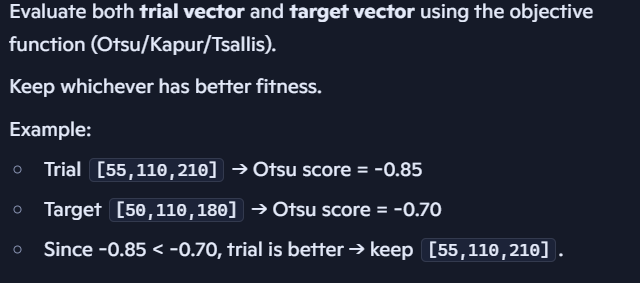

In [23]:
def selection(target, trial, hist, objective_fn):
  if objective_fn(trial, hist) < objective_fn(target, hist):
    return trial
  else:
    return target

**L‑SHADE Implementation**

In [24]:
def lshade(hist, K, objective_fn, pop_size=30, max_gen=100):
  pop = initialize_population(pop_size, K)
  best = None
  memory_F, memory_CR = [0.5], [0.9]

  for gen in range(max_gen):
    current_pop_size = max(4, int(pop_size - (gen/max_gen)*(pop_size-4)))
    pop = pop[:current_pop_size]

    new_pop = []
    for target in pop:
      mutant = mutation(pop, F=np.random.choice(memory_F))
      trial = crossover(target, mutant, CR=np.random.choice(memory_CR))
      selected = selection(target, trial, hist, objective_fn)
      new_pop.append(selected)

    pop = np.array(new_pop)
    scores = [objective_fn(ind, hist) for ind in pop]
    best_idx = np.argmin(scores)
    best = pop[best_idx]
    best_score = scores[best_idx]

  return best, best_score, -best_score

**Performance Evaluation Metrics**

**Peak Signal-to-Noise Ratio (PSNR)**

What it measures: The ratio between the maximum possible pixel value and the error between the original and reconstructed image.

Formula:

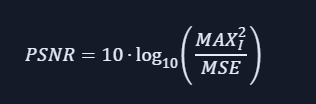

where 𝑀𝐴𝑋𝐼=255 for 8‑bit images, and 𝑀𝑆𝐸 is the mean squared error between original and segmented image.


**Structural Similarity Index (SSIM)**

What it measures: Perceptual similarity between two images, considering luminance, contrast, and structure.

Range: [−1,1], but usually between 0 and 1.

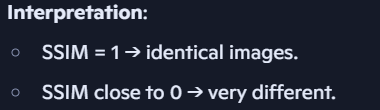

Implementation: skimage.metrics.structural_similarity(original, segmented).



**Feature Uniformity Metric (U)**

What it measures: How uniform the segmented regions are.

Formula (common definition):

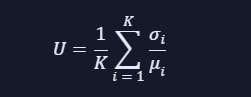

where 𝐾 is the number of regions, 𝜎𝑖 is the standard deviation of pixel intensities in region 𝑖, and 𝜇𝑖 is the mean intensity of region 𝑖.

Interpretation: Lower 𝑈 → more uniform regions (better segmentation).

In [31]:
def compute_metrics(original, segmented, thresholds):
  psnr = peak_signal_noise_ratio(original, segmented)

  ssim = structural_similarity(original, segmented)

  regions = np.digitize(original, segmented)
  U = 0
  for k in range(len(thresholds)+1):
    region_pixels = original[regions == k]
    if len(region_pixels) > 0:
      mu = np.mean(region_pixels)
      sigma = np.std(region_pixels)
      U += sigma / mu if mu != 0 else 0
  U /= (len(thresholds)+1)

  return psnr, ssim, U

**Reconstruct Segmented Image**

In [1]:
def apply_thresholds(img, thresholds):
    thresholds = np.sort(np.round(thresholds).astype(int))
    segmented = np.zeros_like(img)

    # Digitize assigns each pixel to a bin based on thresholds
    regions = np.digitize(img, thresholds)

    # Assign each region its mean intensity
    for k in range(len(thresholds)+1):
        region_pixels = img[regions == k]
        if len(region_pixels) > 0:
            mean_val = np.mean(region_pixels)
            segmented[regions == k] = mean_val

    return segmented

**Running Prototype**

In [2]:
# Experiment Loop
def run_experiments(image_folder, K_values=[3,5,7,9,11,12], trials=30):

    for img_file in os.listdir(image_folder):

        if not (img_file.endswith(".png") or img_file.endswith(".jpg")):
            continue

        img_path = os.path.join(image_folder, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print("Skipping (not an image):", img_path)
            continue

        print("Loaded:", img_path)
        hist = cv2.calcHist([img], [0], None, [256], [0,256])
        hist_norm = hist.flatten() / hist.sum()

        for K in K_values:
            for obj_name, obj_fn in objective_functions.items():
                for trial in range(trials):
                    best_thresholds, raw_score, minimized_score = lshade(hist_norm, K, obj_fn)

                    # Reconstruct segmented image
                    segmented = apply_thresholds(img, best_thresholds)

                    # Compute metrics
                    psnr, ssim, U = compute_metrics(img, segmented, best_thresholds)

                    print(f"Image: {img_file}, Trial: {trial+1}, K={K}, Objective={obj_name}, "
                            f"Best Thresholds={best_thresholds}, Raw Score={raw_score:.4f}, "
                            f"PSNR={psnr:.4f}, SSIM={ssim:.4f}, Uniformity={U:.4f}")


        #plt.plot(hist_norm)
        #plt.title("Normalized Histogram")
        #plt.show()


In [26]:
run_experiments("/content")

Loaded: /content/img3_gt.png


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Image: img3_gt.png, Trial: 1, K=3, Objective=Otsu, Best Thresholds=[ 48.  48. 126.], Raw Score=nan, Minimized Score=nan
Image: img3_gt.png, Trial: 2, K=3, Objective=Otsu, Best Thresholds=[17.80389598 18.24994944 19.8686132 ], Raw Score=-58428.3254, Minimized Score=58428.3254
Image: img3_gt.png, Trial: 3, K=3, Objective=Otsu, Best Thresholds=[4.61770843 5.82403179 6.00778816], Raw Score=-58428.4121, Minimized Score=58428.4121
Image: img3_gt.png, Trial: 4, K=3, Objective=Otsu, Best Thresholds=[4.13197615 5.45600604 6.04119622], Raw Score=-58428.4121, Minimized Score=58428.4121
Image: img3_gt.png, Trial: 5, K=3, Objective=Otsu, Best Thresholds=[4.48307446 5.56212094 6.39020638], Raw Score=-58428.4121, Minimized Score=58428.4121
Image: img3_gt.png, Trial: 6, K=3, Objective=Otsu, Best Thresholds=[4.68291537 5.67555681 6.32946553], Raw Score=-58428.4121, Minimized Score=58428.4121
Image: img3_gt.png, Trial: 7, K=3, Objective=Otsu, Best Thresholds=[4.82102556 5.75052722 6.25808413], Raw Score